# Assignment 2 — Spectral Clustering on Graph Data(CS6890)  
### Team Members —
#### Aayush Ranjan || CS25MTECH11002
#### Mayank Mishra || CS25MTECH11029
#### Prashant Kumar Dubey || CS25MTECH14011

## Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA

N_NODES        = 600
EIGENGAP_LIMIT = 15
KMEANS_INITS   = 10
RANDOM_STATE   = 42
DATA_PATH      = '/content/spectral_graph_600nodes_edges.csv'
ZERO_THRESHOLD = 1e-8

## Step 1 — Load Data

In [ ]:
df = pd.read_csv(DATA_PATH)
print('Shape   :', df.shape)
print('Columns :', df.columns.tolist())
df.head()

Shape   : (6734, 2)
Columns : ['Node 1', 'Node 2']


,Node 1,Node 2
0,0,1
1,0,2
2,0,4
3,0,6
4,0,14


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Build Adjacency Matrix
The CSV is an **edge list** (Node 1 ↔ Node 2). We convert it into a 600×600 adjacency matrix.

In [ ]:
def build_adjacency_matrix(df: pd.DataFrame, n: int) -> np.ndarray:
    A = np.zeros((n, n))
    src = df['Node 1'].to_numpy(dtype=int)
    dst = df['Node 2'].to_numpy(dtype=int)
    A[src, dst] = 1
    A[dst, src] = 1
    return A

A = build_adjacency_matrix(df, N_NODES)
print('Adjacency matrix shape :', A.shape)
print('Number of edges        :', int(A.sum() / 2))

Adjacency matrix shape : (600, 600)
Number of edges        : 6734


## Step 3 — Normalised Laplacian & Eigen decomposition
Graph Laplacian: **L = D − A** where D is the diagonal degree matrix.  
The eigenvalues of L reveal cluster structure.

In [ ]:
def normalized_laplacian(A: np.ndarray) -> np.ndarray:
    degrees = A.sum(axis=1)
    with np.errstate(divide='ignore'):
        d_inv_sqrt = np.where(degrees > 0, 1.0 / np.sqrt(degrees), 0.0)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    return np.eye(len(A)) - D_inv_sqrt @ A @ D_inv_sqrt

L_norm = normalized_laplacian(A)

eigenvalues, eigenvectors = np.linalg.eigh(L_norm)

print('First 10 eigenvalues:')
print(np.round(eigenvalues[:10], 4))

First 10 eigenvalues:
[0.     0.2185 0.2278 0.2328 0.6171 0.6223 0.6244 0.629  0.6317 0.6342]


## Step 4 — Count Connected Components

In [ ]:
n_components = int(np.sum(eigenvalues < ZERO_THRESHOLD))
print(f'\nNumber of connected components: {n_components}')


Number of connected components: 1


## Step 5 — Eigengap Heuristic (choose k)
**Key idea:** The number of clusters = the index k where there is the largest jump between consecutive eigenvalues and the trivial zero eigenvalue at index 0 is excluded.

Gaps between eigenvalues:
  λ[0] → λ[1]: 0.2185
  λ[1] → λ[2]: 0.0093
  λ[2] → λ[3]: 0.0050
  λ[3] → λ[4]: 0.3843  ← largest gap
  λ[4] → λ[5]: 0.0052
  λ[5] → λ[6]: 0.0021
  λ[6] → λ[7]: 0.0046
  λ[7] → λ[8]: 0.0026
  λ[8] → λ[9]: 0.0025
  λ[9] → λ[10]: 0.0065
  λ[10] → λ[11]: 0.0032
  λ[11] → λ[12]: 0.0002
  λ[12] → λ[13]: 0.0019
  λ[13] → λ[14]: 0.0020

→ Optimal number of clusters k = 4


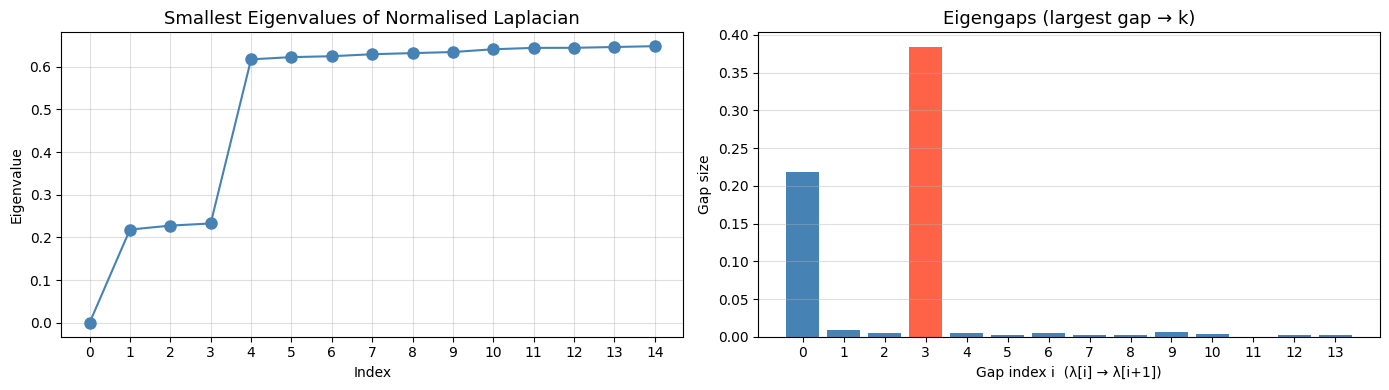

In [ ]:
def eigengap_k(eigenvalues: np.ndarray, limit: int = 15):
    gaps = np.diff(eigenvalues[:limit])
    k = int(np.argmax(gaps)) + 1
    return k, gaps

k, gaps = eigengap_k(eigenvalues, limit=EIGENGAP_LIMIT)

print('Gaps between eigenvalues:')
for i, g in enumerate(gaps):
    marker = '  ← largest gap' if i == k - 1 else ''
    print(f'  λ[{i}] → λ[{i+1}]: {g:.4f}{marker}')
print(f'\n→ Optimal number of clusters k = {k}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(EIGENGAP_LIMIT), eigenvalues[:EIGENGAP_LIMIT],
             'o-', color='steelblue', markersize=8)
axes[0].set_title('Smallest Eigenvalues of Normalised Laplacian', fontsize=13)
axes[0].set_xlabel('Index'); axes[0].set_ylabel('Eigenvalue')
axes[0].set_xticks(range(EIGENGAP_LIMIT))
axes[0].grid(True, alpha=0.4)

bar_colors = ['tomato' if i == k - 1 else 'steelblue' for i in range(len(gaps))]
axes[1].bar(range(len(gaps)), gaps, color=bar_colors)
axes[1].set_title('Eigengaps (largest gap → k)', fontsize=13)
axes[1].set_xlabel('Gap index i  (λ[i] → λ[i+1])')
axes[1].set_ylabel('Gap size')
axes[1].set_xticks(range(len(gaps)))
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

## Step 6 — Spectral Embedding
Take the k eigenvectors corresponding to the k smallest non-zero eigenvalues (skip index 0).

In [ ]:
def spectral_embedding(eigenvectors: np.ndarray, k: int, n_components: int) -> np.ndarray:
    if n_components > 1:
        embedding = eigenvectors[:, :k]
    else:
        embedding = eigenvectors[:, 1:k+1]
    return normalize(embedding, norm='l2', axis=1)

embedding = spectral_embedding(eigenvectors, k, n_components)
print(f'Embedding shape: {embedding.shape}  ({N_NODES} nodes × {k} eigenvectors)')
if n_components > 1:
    print(f'  → Using columns 0 to {k-1} (disconnected graph with {n_components} components)')
else:
    print(f'  → Using columns 1 to {k} (connected graph)')

Embedding shape: (600, 4)  (600 nodes × 4 eigenvectors)
  → Using columns 1 to 4 (connected graph)


## Step 7 — K-Means Clustering

In [ ]:
def run_kmeans(X: np.ndarray, k: int):
    X_scaled = StandardScaler().fit_transform(X)
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_INITS)
    return km.fit_predict(X_scaled), X_scaled

labels, scaled_embedding = run_kmeans(embedding, k)

unique, counts = np.unique(labels, return_counts=True)
print(f'Number of clusters: {k}\n')
print('Cluster sizes:')
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} nodes')

Number of clusters: 4

Cluster sizes:
  Cluster 0: 150 nodes
  Cluster 1: 150 nodes
  Cluster 2: 150 nodes
  Cluster 3: 150 nodes


## Step 8 — 2D PCA Visualization of Clusters

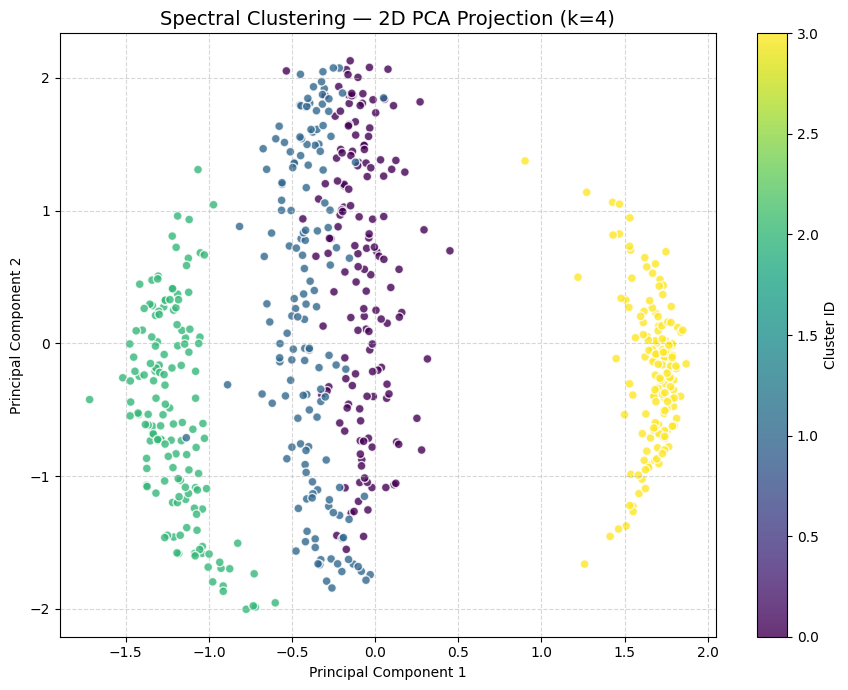

In [ ]:
def plot_2d_pca(X_scaled: np.ndarray, labels: np.ndarray, k: int) -> None:
    reduced = PCA(n_components=2).fit_transform(X_scaled)
    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(reduced[:, 0], reduced[:, 1],
                    c=labels, cmap='viridis', s=40, alpha=0.8, edgecolors='w')
    plt.colorbar(sc, ax=ax, label='Cluster ID')
    ax.set_title(f'Spectral Clustering — 2D PCA Projection (k={k})', fontsize=14)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_2d_pca(scaled_embedding, labels, k)

## Step 8b — 3D PCA Cluster Confirmation

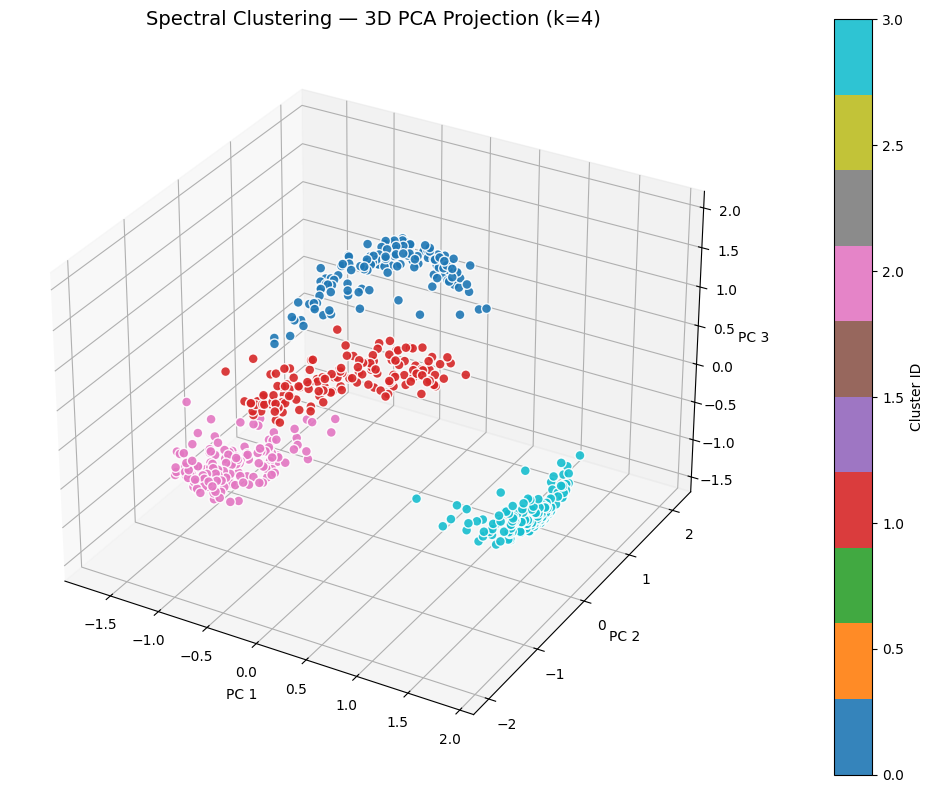

In [ ]:
def plot_3d_pca(X_scaled: np.ndarray, labels: np.ndarray, k: int) -> None:
    reduced = PCA(n_components=3).fit_transform(X_scaled)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(reduced[:, 0], reduced[:, 1], reduced[:, 2],
                    c=labels, cmap='tab10', s=50, alpha=0.9, edgecolors='w')
    plt.colorbar(sc, ax=ax, label='Cluster ID', pad=0.1)
    ax.set_title(f'Spectral Clustering — 3D PCA Projection (k={k})', fontsize=14)
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_zlabel('PC 3')
    plt.tight_layout()
    plt.show()

plot_3d_pca(scaled_embedding, labels, k)

## Step 9 — Cluster Assignment per Node

In [ ]:
result = pd.DataFrame({'Node': range(N_NODES), 'Cluster': labels})
print(result.to_string(index=False))

 Node  Cluster
    0        2
    1        2
    2        2
    3        2
    4        2
    5        2
    6        2
    7        2
    8        2
    9        2
   10        2
   11        2
   12        2
   13        2
   14        2
   15        2
   16        2
   17        2
   18        2
   19        2
   20        2
   21        2
   22        2
   23        2
   24        2
   25        2
   26        2
   27        2
   28        2
   29        2
   30        2
   31        2
   32        2
   33        2
   34        2
   35        2
   36        2
   37        2
   38        2
   39        2
   40        2
   41        2
   42        2
   43        2
   44        2
   45        2
   46        2
   47        2
   48        2
   49        2
   50        2
   51        2
   52        2
   53        2
   54        2
   55        2
   56        2
   57        2
   58        2
   59        2
   60        2
   61        2
   62        2
   63        2
   64        2
   65     

## Final Summary

In [ ]:
print('=== FINAL RESULT ===')
print(f'Number of clusters identified: {k}\n')
for u, c in zip(unique, counts):
    print(f'Cluster {u}: {c} nodes')

=== FINAL RESULT ===
Number of clusters identified: 4

Cluster 0: 150 nodes
Cluster 1: 150 nodes
Cluster 2: 150 nodes
Cluster 3: 150 nodes
